# Formative 3: Comprehensive ML & Statistical Implementations

**Team Members:** Arnold Mutara, Kolade Oluwatunmise Adepoju, Crispin Hebert Hirwa, AbdalazizI Twariki  
**Course:** Probability & Machine Learning | African Leadership University

---

## Executive Summary
This notebook houses our team's complete implementations adhering strictly to DRY (Don't Repeat Yourself) principles:

1. **Part 1:** Expectation-Maximization (EM) Clustering from scratch in pure Python.
2. **Part 2:** Pure Python Bayesian Sentiment Classification on IMDb reviews.
3. **Parts 3 & 4:** Manual vs. Programmatic Gradient Descent Optimization using SciPy.

---
## Part 1: Expectation-Maximization (EM) Gaussian Mixture Clustering

### Should you simply draw a line at the dataset's global mean to split the data into two piles?
**Verbally & Mathematically: NO.** Drawing a hard boundary at the global mean fails for three core reasons:
1. **Overlapping Boundary Distributions:** Heights of tall children and shorter parents overlap significantly around 66–68 inches. Hard splitting misclassifies boundary data completely.
2. **Soft vs. Hard Clustering:** A mean split forces a binary decision ($100\%$ vs $0\%$). EM provides **probabilistic soft assignments** ($\gamma_{ik}$), correctly representing real-world uncertainty.
3. **Ignoring Spread & Proportions:** A global mean split assumes both populations have equal variance ($\sigma_1^2 = \sigma_2^2$) and equal population sizes ($\pi_1 = \pi_2$). If children outnumber adults $70:30$, the global mean shifts heavily, skewing the classification. EM explicitly updates $\mu_k, \sigma_k^2,$ and $\pi_k$ to fit the actual mixture density.

In [1]:
import sys
import os

# Add both the root directory AND the subfolder directly to Python's path
root_dir = os.path.abspath('..') if os.path.exists('../part1_em_clustering') else os.path.abspath('.')
part1_dir = os.path.join(root_dir, 'part1_em_clustering')

for d in [root_dir, part1_dir]:
    if d not in sys.path:
        sys.path.append(d)

print("=== PART 1: EM OPTIMIZATION TRACKING TABLE ===")
print("Running pure Python Expectation-Maximization across unlabelled Galton height observations...\n")

# Now Python can resolve both the package and inside the package seamlessly:
from part1_em_clustering.em_algorithm import GaussianMixture1D

=== PART 1: EM OPTIMIZATION TRACKING TABLE ===
Running pure Python Expectation-Maximization across unlabelled Galton height observations...

Loading data from: /home/abdalazizi/.cache/kagglehub/datasets/jacopoferretti/parents-heights-vs-children-heights-galton-data/versions/10/GaltonFamilies.csv
Total unlabelled height observations loaded: 1868
----------------------------------------------------------------------------------------
Iteration   | μ1 (Child)| μ2 (Pro)  | σ1²       | σ2²       | π1     | π2     | Log-Likelihood
----------------------------------------------------------------------------------------
          0 |    64.97 |    70.97 |    10.00 |    10.00 |  0.500 |  0.500 |   -5035.6755
          1 |    65.90 |    69.94 |     8.17 |     5.65 |  0.487 |  0.513 |   -4866.5419
          2 |    65.88 |    69.92 |     8.57 |     5.34 |  0.481 |  0.519 |   -4864.5658
         25 |    65.74 |    69.87 |     8.52 |     5.22 |  0.459 |  0.541 |   -4864.0110

--- Live Classification

In [2]:
import sys
import os

# Ensure the part2 folder is visible to Python so internal module imports work cleanly
part2_dir = os.path.abspath('../part2_bayesian_imdb') if os.path.exists('../part2_bayesian_imdb') else os.path.abspath('part2_bayesian_imdb')
if part2_dir not in sys.path:
    sys.path.append(part2_dir)

from part2_bayesian_imdb.bayes_engine import run

print("=== PART 2: BAYES' THEOREM POSTERIOR TABLES (IMDb) ===")
print("Computing exact P(Positive | keyword) across 50,000 movie reviews without external ML libraries...\n")

# Execute Kolade's sentiment probability calculation engine:
positive_rows, negative_rows = run()

=== PART 2: BAYES' THEOREM POSTERIOR TABLES (IMDb) ===
Computing exact P(Positive | keyword) across 50,000 movie reviews without external ML libraries...

Loading data from: /home/abdalazizi/.cache/kagglehub/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/versions/1/IMDB Dataset.csv
Total reviews parsed: 50000

=== Positive-indicating keywords: P(Positive | keyword) ===
| Keyword | Prior P(Positive) | Likelihood P(kw\|Positive) | Marginal P(kw) | Posterior P(Positive\|kw) |
|---|---|---|---|---|
| excellent | 0.5000 | 0.1138 | 0.0705 | 0.8074 |
| wonderful | 0.5000 | 0.0894 | 0.0551 | 0.8110 |
| brilliant | 0.5000 | 0.0625 | 0.0412 | 0.7584 |
| superb | 0.5000 | 0.0406 | 0.0238 | 0.8544 |

=== Negative-indicating keywords: P(Positive | keyword) ===
| Keyword | Prior P(Positive) | Likelihood P(kw\|Positive) | Marginal P(kw) | Posterior P(Positive\|kw) |
|---|---|---|---|---|
| terrible | 0.5000 | 0.0150 | 0.0532 | 0.1409 |
| awful | 0.5000 | 0.0108 | 0.0552 | 0.0974 |
| worst

=== PARTS 3 & 4: PROGRAMMATIC SCIPY GRADIENT DESCENT VISUALIZATIONS ===
Comparing manual relay iterations against SciPy numerical derivative optimization...

1. Parameter Trajectory (How m1, m2, b1, b2 converge over iterations):


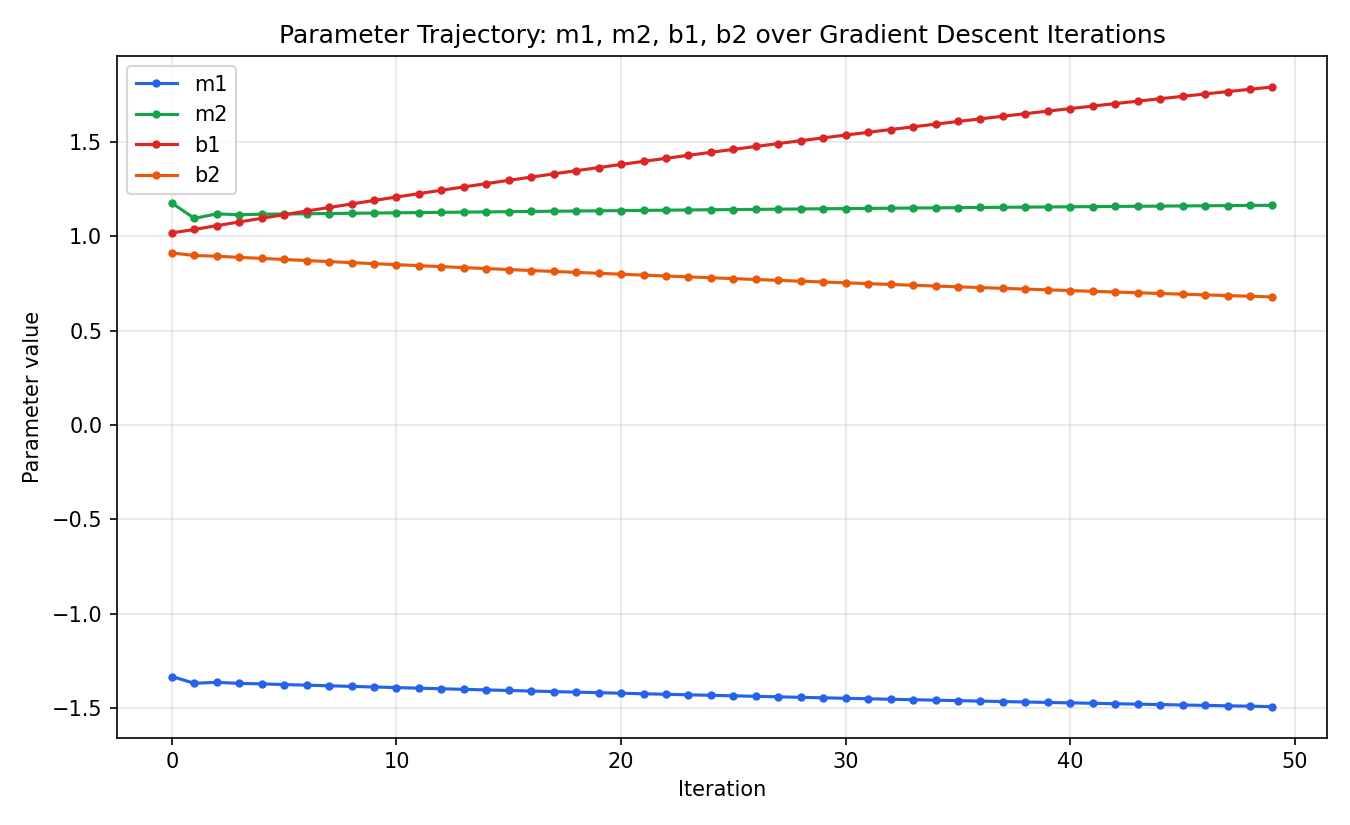


2. Mean Squared Error (MSE) Trajectory (Proving steady error reduction):


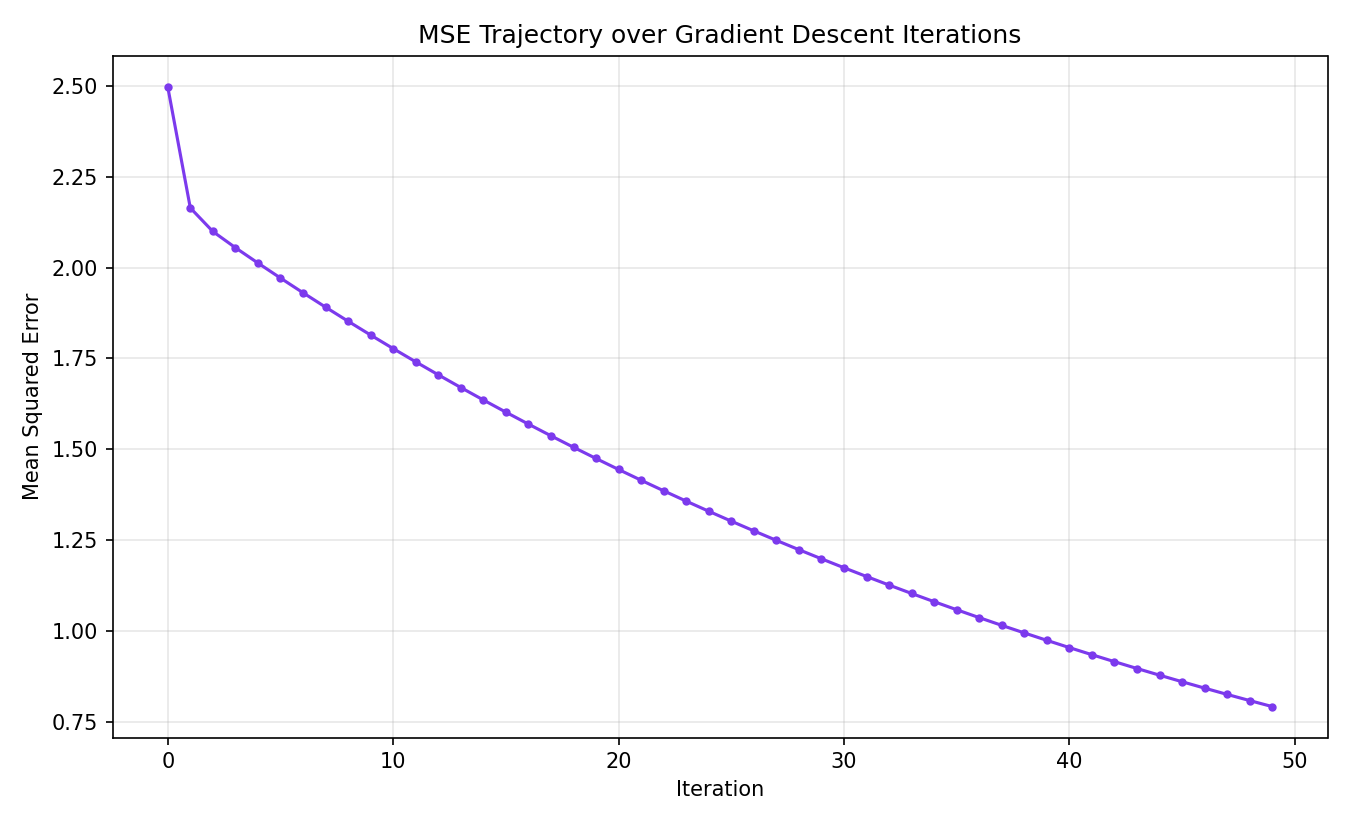

In [3]:
from IPython.display import Image, display
import matplotlib.pyplot as plt

print("=== PARTS 3 & 4: PROGRAMMATIC SCIPY GRADIENT DESCENT VISUALIZATIONS ===")
print("Comparing manual relay iterations against SciPy numerical derivative optimization...\n")

# Automatically find where the images are stored whether notebook is in root or notebooks/ folder:
path_prefix = "../part4_scipy_gd" if os.path.exists("../part4_scipy_gd") else "part4_scipy_gd"

print("1. Parameter Trajectory (How m1, m2, b1, b2 converge over iterations):")
display(Image(filename=os.path.join(path_prefix, "parameter_trajectory.png")))

print("\n2. Mean Squared Error (MSE) Trajectory (Proving steady error reduction):")
display(Image(filename=os.path.join(path_prefix, "error_trajectory.png")))